# 09. your own analysis

### CAJAL Neuromics Summer School, Bordeaux 2026 · a spatial metabolomics primer

This is the last notebook, and it is almost empty on purpose. The ones before it walked
you down a fixed path: load the raw METASPACE ions, annotate them, normalize with uMAIA,
embed, cluster into your own lipizones, and test which lipids change in pregnancy. Every
step was scaffolded. 

Now the scaffold comes off. You pick a question, you choose the tools, you run the analysis,
and you defend the result. 

You will not be alone. You have the `cajal_lipidomics` helpers, you have the data you built
yourself stage by stage, you have the finished notebooks as a reference library, and you
have Claude Code next to you to write code on demand. The skill this notebook trains is not
typing. It is steering: deciding what to ask, judging what comes back, and noticing when
something is wrong.

In [ ]:
# the scientific-Python stack, the course helpers, the data you built
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import anndata as ad
import cajal_lipidomics as cl
from cajal_lipidomics import analysis, plotting, embedding, multimodal, annotation
from cajal_lipidomics.style import set_style
set_style()  # the course-wide figure look: clean axes, vector text, fixed font sizes

# one global seed so every number and figure below is reproducible
SEED = 0
np.random.seed(SEED)

loaded 189011 pixels x 104 ions (63 annotated to a lipid name)
conditions: {'pregnant': 100258, 'naive': 88753}
your own lipizones: 26


## the planning template

Every good analysis starts on paper, not in code. Before you write a single line, fill in the six
boxes below. They are the same six a grant reviewer, a thesis committee, or your own future self
will ask about. Filling them honestly is half the work, and it is the half that stops you from
spending an afternoon computing something nobody asked for.

🔬 **TASK.** Copy the template in the next cell, then replace every `...` with your own words.
Keep it short. One or two sentences per box is plenty. Do this before you touch the data.

In [6]:
# ===========================  MY PROJECT PLAN  ===========================
#
# QUESTION
#   The one specific thing I want to know.
#   ...
#
# WHY IT MATTERS
#   What it would change about how we read the brain, the data, or the paper.
#   ...
#
# DATA
#   Exactly which pixels, lipids, regions, conditions, or external tables I will use,
#   and where they live (which adata.obs column? which lipid in var_names? the MERFISH
#   parquet?).
#   ...
#
# STRATEGY
#   The sequence of steps and which cl.<helper> performs each one.
#   ...
#
# WHAT RESULT WOULD ANSWER IT
#   The concrete number, figure, or comparison that says yes or no. Decide the
#   threshold NOW, before you see the answer, so you cannot move the goalposts.
#   ...
#
# WHAT COULD GO WRONG
#   Batch vs biology (we have only 2 sections), too few pixels, a confound, a
#   registration error, an annotation that is actually isobaric. Name the failure
#   mode you most fear, and how you would detect it.
#   ...
# =========================================================================
print("plan written. now, and only now, open the data.")

plan written. now, and only now, open the data.


💡 **HINT.** The hardest box is usually *what result would answer it*. If you cannot name
the figure or the number in advance, your question is still too vague. Narrow it until the answer
is a single plot you can imagine before you draw it.

🔬 **TASK.** Run direction A once, end to end, so the paper claim stops being a claim and
becomes a number you watched come out of code. We build a white-matter mask from Allen acronyms,
score myelination per pixel, and compare control to pregnant in the tracts against grey matter as a
control.

In [7]:
# direction A, worked: does the myelination signal rise in pregnant white matter?
# 1) score every pixel: mean z-scored sphingolipid (HexCer / Cer / SM) intensity
adata.obs["myelination"] = analysis.myelination_score(adata)

# 2) build a white-matter mask from Allen acronyms (the tracts present in both sections)
wm_acronyms = ["cc", "ccg", "fi", "int", "alv", "ec", "scwm", "or",
               "opt", "st", "fx", "em", "py", "arb", "fp", "df"]
wm = adata.obs["acronym"].astype(str).isin(wm_acronyms).values
gm = ~wm  # everything else, as a control: the rise should be specific to the tracts
print(f"white matter: {int(wm.sum())} pixels   grey matter: {int(gm.sum())} pixels")

# 3) compare the mean myelination score, control ('naive') vs pregnant, in each compartment
def mean_score(mask, cond):
    sel = mask & (adata.obs["Condition"] == cond).values
    return float(adata.obs["myelination"].values[sel].mean())

print("\nmyelination score (mean over pixels):")
print(f"  white matter : naive {mean_score(wm, 'naive'):+.3f}  ->  pregnant {mean_score(wm, 'pregnant'):+.3f}")
print(f"  grey matter  : naive {mean_score(gm, 'naive'):+.3f}  ->  pregnant {mean_score(gm, 'pregnant'):+.3f}")

white matter: 11147 pixels   grey matter: 177864 pixels

myelination score (mean over pixels):
  white matter : naive +0.272  ->  pregnant +0.418
  grey matter  : naive -0.009  ->  pregnant -0.034


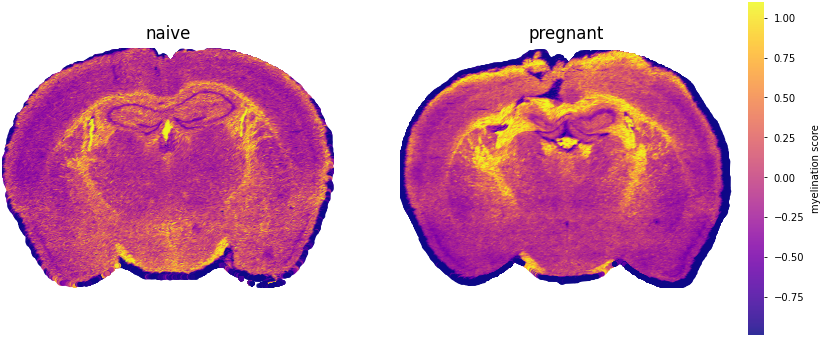

In [8]:
# the number is only half the answer; now look. paint the myelination score on both sections.
# we stash it as a temporary 'lipid' column so the spatial helper can map it on the shared scale.
adata.var_names = list(adata.var_names)  # plain list, so we can append a synthetic column safely
score_view = ad.AnnData(
    X=adata.obs["myelination"].values.reshape(-1, 1).astype("float32"),
    obs=adata.obs,
)
score_view.var_names = ["myelination score"]
plotting.spatial_lipid(score_view, "myelination score")
plt.show()

**check:** in your two sections the white-matter myelination score should come out **higher
in pregnant than control**, while grey matter stays roughly flat (or even dips a touch). That is the
*same direction* as the paper's claim of broad pregnancy myelination, reached from your own ions and
a far simpler score. The spatial map should show the tracts a touch brighter in the pregnant panel,
which is the picture behind the number. We have confirmed the *direction*, not the exact effect size:
one section per condition and a sum-of-sphingolipids score is not the paper's six-mouse Bayesian
model. This is the honest version of the claim, a verification path that runs with its limits stated
out loud. Now do the same for a claim of your own.

## using Claude Code well

You have an AI coding assistant for this project. Used well it is the best lab partner you will ever
have. Used badly it is a confident liar that wastes your afternoon. The difference is entirely in how
you supervise it. Four rules.

**Read what it writes, every line.** Never run code you do not understand. If the assistant produces
a block you cannot follow, ask it to explain that block before you run it, or ask it to rewrite it
more simply. The unrolled, transparent style of these notebooks exists so that you *can* read the
code. Keep that standard for the code the assistant gives you.

**Verify against reality, not against its confidence.** The assistant will state results in a sure
voice whether or not they are true. Check them. Did the cell actually run, or did it error and the
assistant move on? Does the pixel count match the check? Does the fold change have a plausible sign
and size? Print intermediate shapes and a few values. A number you have not seen printed by code that
ran is not a result, it is a guess.

**Iterate in small steps.** Ask for one cell at a time, run it, look at the output, then ask for the
next. A giant block that does everything at once is impossible to debug and easy to get subtly wrong.
Small steps with a printout after each are how you keep control.

**Give it the context it needs.** Tell it the data lives in `adata`, with `adata.X` as the
uMAIA-normalized intensities, `adata.var_names` named by lipid, your own labels in
`adata.obs['lipizone']`, and the `.obs` columns listed above. Point it at the helper source in
`src/cajal_lipidomics/`. Tell it we have exactly two sections and no biological replicates, so it
does not propose a replicate-level statistic we cannot run. The more precisely you frame the task,
the better the code.